# ISyE 6525 HW3 — Question 3: Heat Transfer with CP-ALS

This notebook is a **step-by-step scaffold**. The goal is for you to implement CP-ALS yourself, as required by the assignment, rather than calling `cp_als`, TensorLy, or an equivalent library routine.

## Deliverables

- **Q3(a)** Implement CP-ALS. For each of `tensor1`, `tensor2`, and `tensor3`, fit ranks $R=1,\ldots,8$, compute
  $$
  \mathrm{AIC}(R)=2\left\|\mathcal X-\sum_{r=1}^R \lambda_r a_r\circ b_r\circ c_r\right\|_F^2+2R,
  $$
  plot AIC versus rank, and report the minimizing rank.
- **Q3(b)** At the selected rank for `tensor1`, plot the temporal loadings $c_r$ and the leading spatial patterns $\lambda_r a_r\circ b_r$. Interpret them physically.
- **Q3(c)** Determine whether `tensor3` corresponds to material 1 or material 2 using quantities derived from the CP factors. State exactly what you compare and why.

### Working rule

Do not move on when a shape is unclear. CP-ALS bugs are usually **unfolding / Khatri-Rao ordering bugs**, not difficult mathematics.


In [15]:
from pathlib import Path
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

np.set_printoptions(precision=5, suppress=True)

DATA_PATH = Path("heatT.mat")
RANKS = range(1, 9)
SEED = 25
MAX_ITER = 500
TOL = 1e-8

# Optional: because CP-ALS uses random initialization and can reach different local minima.
N_RESTARTS = 3


## 1. Load and inspect the heat-transfer tensors

4. Display a few time frames before doing any factorization. This catches axis-order mistakes early.


In [ ]:
mat = loadmat(DATA_PATH)
print("MAT keys:", [k for k in mat.keys() if not k.startswith("__")])

tensor1 = np.asarray(mat["tensor1"], dtype=float)
tensor2 = np.asarray(mat["tensor2"], dtype=float)
tensor3 = np.asarray(mat["tensor3"], dtype=float)

for name, X in {"tensor1": tensor1, "tensor2": tensor2, "tensor3": tensor3}.items():
    print(name, X.shape, X.dtype, "min/max:", X.min(), X.max())
    assert X.shape == (21, 21, 10), f"Unexpected shape for {name}: {X.shape}"


MAT keys: ['tensor1', 'tensor2', 'tensor3']
tensor1 (21, 21, 10) float64 min/max: -0.0513963231074558 1.0205862845417446
tensor2 (21, 21, 10) float64 min/max: 0.008626124315785313 1.0492322056294945
tensor3 (21, 21, 10) float64 min/max: -0.04823357206516501 1.024715289724924


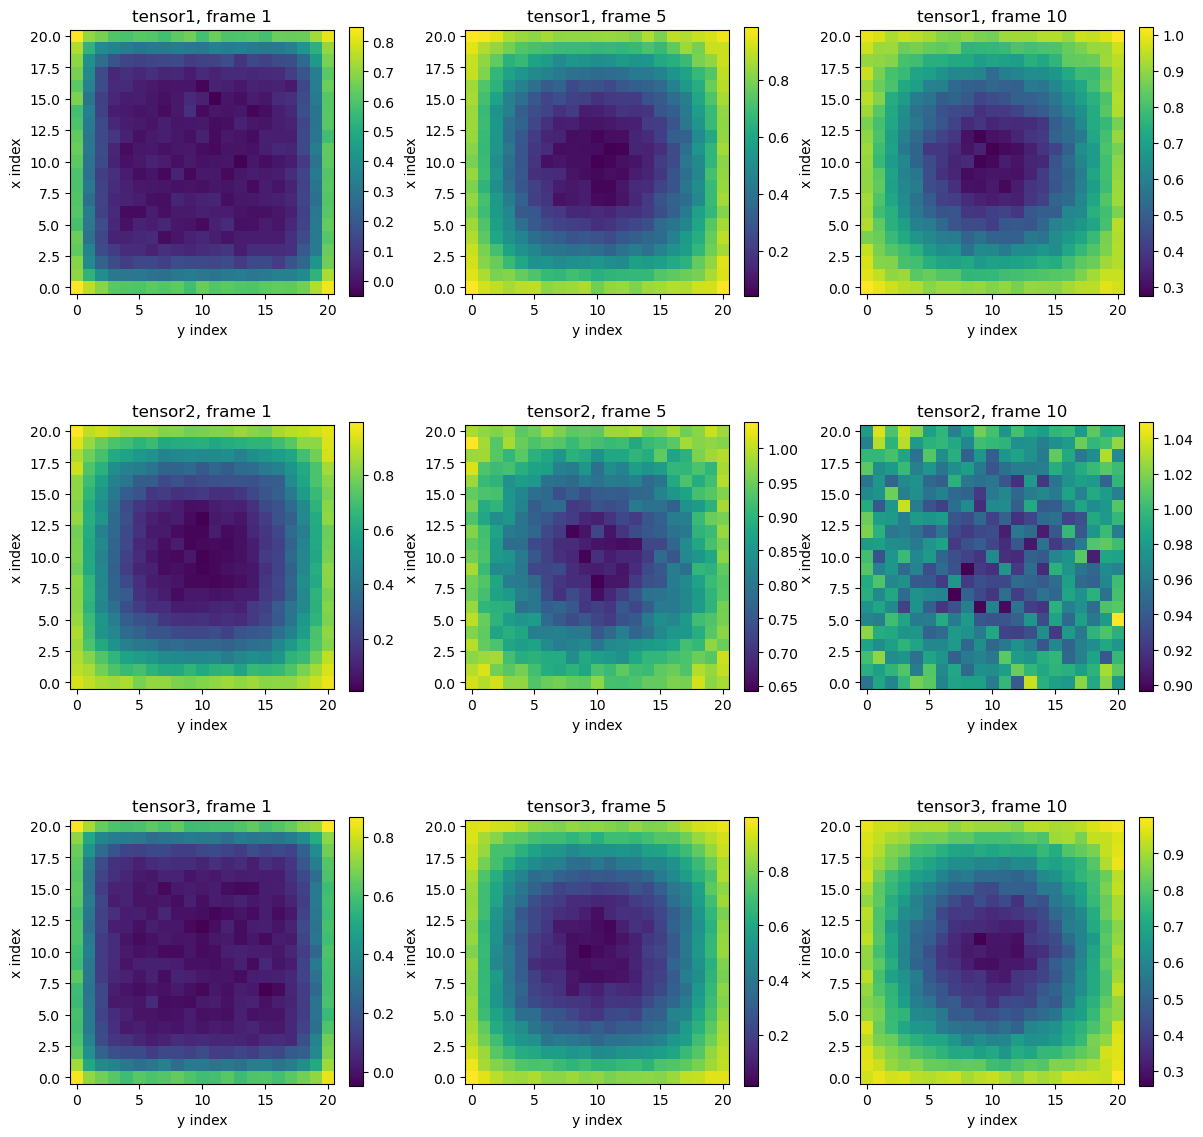

In [9]:
# TODO: visualize a few raw frames from tensor1, then repeat for tensor2/tensor3 if useful.
frames = [0, 4, 9]  # Python indices for time frames 1, 5, 10

fig, axes = plt.subplots(3, len(frames), figsize=(12, 12))
for i, tensor in enumerate([tensor1, tensor2, tensor3]):
    for j, k in enumerate(frames):
        ax = axes[i, j]
        im = ax.imshow(tensor[:, :, k], origin="lower")
        ax.set_title(f"tensor{i + 1}, frame {k + 1}")
        ax.set_xlabel("y index")
        ax.set_ylabel("x index")
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


## 2. Build the tensor primitives first

For a third-order tensor $\mathcal X\in\mathbb R^{I\times J\times K}$, choose **one unfolding convention and keep it consistent**.

With the convention used in the lecture,
$$
X_{(1)} \approx A\Lambda(C\odot B)^\top,
$$
so the Khatri-Rao ordering matters.

You need three small primitives:

1. `unfold(X, mode)`
2. `khatri_rao(A, B)`
3. `cp_reconstruct(weights, factors)`

Do not start CP-ALS until these pass tiny synthetic tests.


In [16]:
def unfold(X: np.ndarray, mode: int) -> np.ndarray:
    """Mode-n unfolding.

    Target shape:
        X.shape = (I0, I1, I2)
        output.shape = (X.shape[mode], product(other dimensions))
    
    """
    X_mode = np.moveaxis(X, mode, 0)
    return X_mode.reshape(X.shape[mode], -1)


def khatri_rao(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Column-wise Kronecker product.

    If A is (I, R) and B is (J, R), return (I*J, R), with column r:
        kron(A[:, r], B[:, r]).

    # A: shape (I, R) -> reshape to (I, 1, R)
    # B: shape (J, R) -> reshape to (1, J, R)
    # Element-wise multiplication broadcasts to (I, J, R)
    """
    out = A[:, None, :] * B[None, :, :]
    # Flatten the first two dimensions back into a 2D matrix
    R = A.shape[1]
    return out.reshape(-1, R)


def cp_reconstruct(weights: np.ndarray, factors: list[np.ndarray]) -> np.ndarray:
    """Reconstruct sum_r lambda_r * a_r o b_r o c_r.

    factors = [A, B, C] with shapes (I,R), (J,R), (K,R).

    """
    A, B, C = factors
    I, J, K = A.shape[0], B.shape[0], C.shape[0]
    R = A.shape[1]
    X_hat = np.zeros((I, J, K))
    for r in range(R):
        X_hat += weights[r] * np.einsum('i,j,k->ijk', A[:, r], B[:, r], C[:, r])
    return X_hat


### 2.1 Synthetic tests

Before touching the homework data, make a tensor whose CP representation you know exactly.

If
$$
\mathcal X = 2a_1\circ b_1\circ c_1 - 0.5a_2\circ b_2\circ c_2,
$$
then reconstruction from those exact factors should have numerical error near machine precision.

Also verify the matricized CP identity for **your** unfolding convention. This is the critical test for Khatri-Rao ordering.


In [14]:
rng = np.random.default_rng(SEED)
I, J, K, R = 3, 4, 5, 2
A = rng.normal(size=(I, R))
B = rng.normal(size=(J, R))
C = rng.normal(size=(K, R))
w = np.array([2.0, -0.5])

X_syn = cp_reconstruct(w, [A, B, C])
assert X_syn.shape == (I, J, K)

# Check one unfolding identity. Depending on your unfold convention,
# you may need C ⊙ B versus B ⊙ C. Determine it empirically and then keep it fixed.

lhs = unfold(X_syn, 0)
rhs_candidate_1 = (A * w) @ khatri_rao(C, B).T
rhs_candidate_2 = (A * w) @ khatri_rao(B, C).T

print("candidate C⊙B error:", np.linalg.norm(lhs - rhs_candidate_1))
print("candidate B⊙C error:", np.linalg.norm(lhs - rhs_candidate_2))


candidate C⊙B error: 10.120120040498213
candidate B⊙C error: 4.004243828756106e-16


## 3. Implement CP-ALS

For one mode at a time, hold the other factor matrices fixed and solve a matrix least-squares problem.

For mode 1,
$$
X_{(1)} \approx A(C\odot B)^\top.
$$

Equivalently, the normal-equation structure uses
$$
(C^\top C) * (B^\top B),
$$
where $*$ is the Hadamard product.

### Implementation plan

For each ALS sweep:

1. Update $A$ using $B,C$.
2. Update $B$ using $A,C$.
3. Update $C$ using $A,B$.
4. Normalize the columns and accumulate/store the component weights $\lambda_r$.
5. Reconstruct $\hat{\mathcal X}$, compute the squared residual, and check convergence.

### Numerical advice

- Prefer `np.linalg.solve` or `np.linalg.pinv` over explicitly forming a matrix inverse.
- Use a fixed random seed while debugging.
- Keep a loss history.
- If a column norm becomes effectively zero, handle it explicitly rather than dividing by zero.


In [19]:
def normalize_columns(M: np.ndarray, eps: float = 1e-12):
    """Return normalized columns and their norms."""
    norm = np.linalg.norm(M, axis=0) + eps
    return M / norm, norm


def cp_als(
    X: np.ndarray,
    rank: int,
    *,
    max_iter: int = MAX_ITER,
    tol: float = TOL,
    seed: int = SEED,
    verbose: bool = False,
):
    """CP-ALS implemented from scratch.

    Returns
    -------
    weights : (R,)
    factors : [A1, A2, A3, ...]
    history : dict containing at least squared residual per iteration

    TODO checklist
    --------------
    [ ] Initialize factors matrices with random entries.
    [ ] For each mode, form the Khatri-Rao product of the *other* factors
        in the order required by your unfolding convention.
    [ ] Form the Hadamard product of the other Gram matrices.
    [ ] Solve the least-squares / normal-equation update.
    [ ] Normalize columns.
    [ ] Track component weights consistently.
    [ ] Reconstruct X_hat and compute ||X - X_hat||_F^2.
    [ ] Stop when relative objective change < tol.
    [ ] Return factors in a convention where cp_reconstruct() reproduces the fit.

    IMPORTANT:
    CP factors have permutation/sign/scaling ambiguities. Correctness means
    reconstruction is correct; do not expect columns to match another run exactly.
    """
    rng = np.random.default_rng(seed)

    A = []
    weights = np.ones(rank)
    for dim in X.shape:
        A.append(rng.normal(size=(dim, rank)))

    history = {"sse": []}
    for iteration in range(max_iter):
        for k in range(X.ndim):
            grams = [A[j].T @ A[j] for j in range(X.ndim) if j != k]
            V = reduce(np.dot, grams)
            Z = reduce(khatri_rao, [A[j] for j in range(X.ndim) if j != k])
            A[k] = unfold(X, k) @ Z @ np.linalg.pinv(V)
            A[k], norm = normalize_columns(A[k])
            weights = norm
        X_hat = cp_reconstruct(weights, A)
        sse = np.sum((X - X_hat) ** 2)
        history["sse"].append(sse)
        if verbose:
            print(f"Iteration {iteration}, SSE: {sse}")
        if iteration > 0 and abs(history["sse"][-2] - sse) / history["sse"][-2] < tol:
            break

    return weights, A, history


## 4. Validate CP-ALS on synthetic data

Do not run the rank sweep until this works.

Recommended checks:

- Rank-1 exact tensor should reconstruct almost exactly with `rank=1`.
- Rank-2 synthetic tensor should reconstruct very accurately with `rank=2`.
- SSE should generally decrease across ALS sweeps.
- `cp_reconstruct(weights, factors)` must have the original tensor shape.


synthetic relative error: 0.6309916362734163


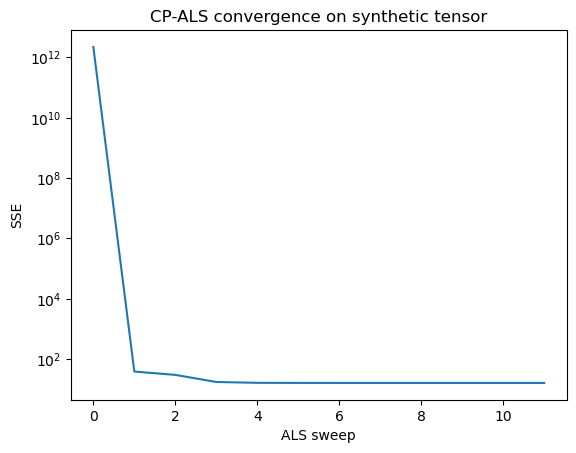

In [20]:
rng = np.random.default_rng(SEED)

weights, factors, history = cp_als(X_syn, rank=2, seed=SEED)
X_hat = cp_reconstruct(weights, factors)
rel_err = np.linalg.norm(X_syn - X_hat) / np.linalg.norm(X_syn)
print("synthetic relative error:", rel_err)

plt.plot(history["sse"])
plt.yscale("log")
plt.xlabel("ALS sweep")
plt.ylabel("SSE")
plt.title("CP-ALS convergence on synthetic tensor")
plt.show()


## 5. Q3(a): rank sweep and AIC

The assignment's criterion is
$$
\mathrm{AIC}(R)=2\|\mathcal X-\hat{\mathcal X}_R\|_F^2+2R.
$$

For each of the three tensors and each $R=1,\ldots,8$:

1. Fit CP-ALS.
2. Compute $\hat{\mathcal X}_R$.
3. Compute SSE.
4. Compute AIC exactly as stated above.
5. Save the best fit/factors for later parts.
6. Select the rank with minimum AIC.

Because random initialization can matter, the scaffold includes `N_RESTARTS`. Keep the fit with the smallest SSE for each rank.


In [21]:
def fit_best_cp_restart(X, rank, n_restarts=N_RESTARTS):
    """Run CP-ALS several times and keep the fit with minimum SSE."""
    best = None
    for restart in range(n_restarts):
        weights, factors, history = cp_als(X, rank, seed=SEED + restart)
        sse = history["sse"][-1]
        if best is None or sse < best["sse"]:
            best = dict(weights=weights, factors=factors, sse=sse, history=history, X_hat=cp_reconstruct(weights, factors))
    return best


def cp_aic(sse: float, rank: int) -> float:
    # Assignment definition — do not silently replace this by another AIC convention.
    return 2.0 * sse + 2.0 * rank


In [23]:
tensors = {
    "tensor1": tensor1,
    "tensor2": tensor2,
    "tensor3": tensor3,
}

results = {}
for name, X in tensors.items():
    results[name] = {}
    for R in RANKS:
        fit = fit_best_cp_restart(X, R)
        fit["aic"] = cp_aic(fit["sse"], R)
        results[name][R] = fit

selected_rank = {
    name: min(per_rank, key=lambda R: per_rank[R]["aic"])
    for name, per_rank in results.items()
}
print("Selected ranks:", selected_rank)


Selected ranks: {'tensor1': 1, 'tensor2': 1, 'tensor3': 1}


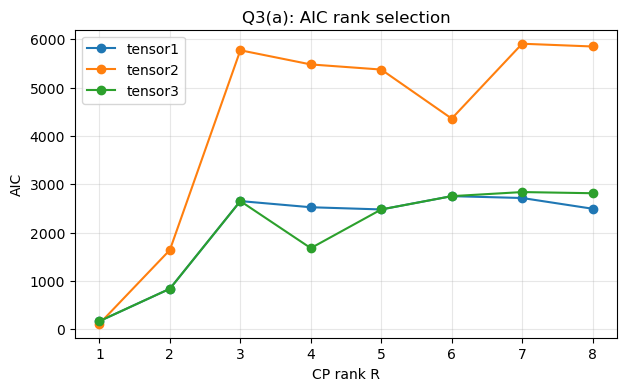

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, per_rank in results.items():
    ranks = list(per_rank)
    aics = [per_rank[R]["aic"] for R in ranks]
    ax.plot(ranks, aics, marker="o", label=name)
ax.set_xlabel("CP rank R")
ax.set_ylabel("AIC")
ax.set_title("Q3(a): AIC rank selection")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 6. Q3(b): temporal loadings and spatial patterns for tensor1

At the selected rank $R_1^*$, CP gives
$$
\hat{\mathcal X}
=
\sum_{r=1}^{R_1^*}
\lambda_r a_r\circ b_r\circ c_r.
$$

For each component:

- $c_r\in\mathbb R^{10}$ is its temporal loading.
- $\lambda_r a_r b_r^\top\in\mathbb R^{21\times 21}$ is its spatial pattern.

### TODO

1. Retrieve the selected fit for `tensor1`.
2. Sort components by a clearly stated rule (for example decreasing $|\lambda_r|$).
3. Plot every $c_r(t)$.
4. Display the leading spatial patterns as images.
5. Interpret what changes in time and what each spatial component appears to represent.

Remember: CP component sign is arbitrary. If you flip the sign of one factor and compensate in another, the reconstructed tensor is unchanged. Interpret the **joint component**, not the sign of an isolated factor.


In [ ]:
# TODO: retrieve and sort tensor1 components.
#
# R1 = selected_rank["tensor1"]
# fit1 = results["tensor1"][R1]
# weights1 = fit1["weights"].copy()
# A1, B1, C1 = [F.copy() for F in fit1["factors"]]
#
# order = np.argsort(-np.abs(weights1))
# weights1 = weights1[order]
# A1, B1, C1 = A1[:, order], B1[:, order], C1[:, order]


In [ ]:
# TODO: plot temporal loadings.
#
# t = np.arange(1, 11)
# fig, ax = plt.subplots(figsize=(8, 4))
# for r in range(R1):
#     ax.plot(t, C1[:, r], marker="o", label=f"component {r+1}")
# ax.set_xlabel("Time frame")
# ax.set_ylabel("Temporal loading")
# ax.set_title("tensor1 temporal CP loadings")
# ax.legend()
# ax.grid(alpha=0.3)
# plt.show()


In [ ]:
# TODO: display leading spatial patterns lambda_r * a_r b_r^T.
#
# n_show = min(R1, 6)
# fig, axes = plt.subplots(1, n_show, figsize=(3.5*n_show, 3.5), squeeze=False)
# for r in range(n_show):
#     spatial = weights1[r] * np.outer(A1[:, r], B1[:, r])
#     ax = axes[0, r]
#     im = ax.imshow(spatial, origin="lower")
#     ax.set_title(f"component {r+1}")
#     fig.colorbar(im, ax=ax, fraction=0.046)
# plt.tight_layout()


## 7. Q3(c): identify tensor3 using CP-derived dynamics

The physical difference between materials is the thermal diffusivity $\alpha$, so the strongest discriminating signal should be **how the spatial temperature field evolves over time**.

A robust CP-derived quantity is the mean reconstructed temperature trajectory:
$$
\bar S(t)
=
\frac{1}{IJ}\sum_{i,j}\hat X_{ijt}
=
\sum_r \lambda_r\,\overline{a_r}\,\overline{b_r}\,c_r(t).
$$

Why this is useful:

- It is computed directly from the CP factors.
- It is invariant to CP component permutation.
- It is unaffected by the usual CP sign/scaling rearrangements as long as the reconstruction is unchanged.
- It has a direct physical interpretation as the overall heating trajectory.

### TODO

1. Compute this CP-derived trajectory for materials 1, 2, and tensor3 using each tensor's selected-rank model.
2. Plot all three trajectories.
3. Choose a distance measure before looking at the result, e.g. RMSE between trajectories.
4. Compare `tensor3` to material 1 and material 2.
5. State the nearer match and explain why this quantity reflects thermal diffusivity.

As a secondary check, you may also compare normalized temporal factor subspaces / matched temporal components, but do not rely on raw column order because CP components can be permuted.


In [ ]:
def cp_mean_trajectory(weights, factors):
    """Mean over spatial modes computed directly from CP factors."""
    # TODO:
    # A, B, C = factors
    # spatial_scale = weights * A.mean(axis=0) * B.mean(axis=0)
    # return C @ spatial_scale
    raise NotImplementedError


# TODO: compute and compare selected-rank trajectories.
#
# trajectories = {}
# for name in tensors:
#     R = selected_rank[name]
#     fit = results[name][R]
#     trajectories[name] = cp_mean_trajectory(fit["weights"], fit["factors"])
#
# for name, y in trajectories.items():
#     plt.plot(np.arange(1, 11), y, marker="o", label=name)
# plt.xlabel("Time frame")
# plt.ylabel("CP-derived mean reconstructed temperature")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()
#
# d31 = np.sqrt(np.mean((trajectories["tensor3"] - trajectories["tensor1"])**2))
# d32 = np.sqrt(np.mean((trajectories["tensor3"] - trajectories["tensor2"])**2))
# print("RMSE(tensor3, material1):", d31)
# print("RMSE(tensor3, material2):", d32)


## 8. Final Q3 report checklist

Before exporting/submitting:

- [ ] CP-ALS is your own implementation.
- [ ] Synthetic reconstruction tests pass.
- [ ] All three tensors were fit for ranks 1 through 8.
- [ ] AIC uses the **assignment's exact formula**.
- [ ] AIC-vs-rank plot is included and optimal ranks are reported.
- [ ] Tensor1 temporal loadings are plotted.
- [ ] Leading spatial patterns $\lambda_r a_r\circ b_r$ are displayed.
- [ ] Physical interpretation is written in words, not only shown in plots.
- [ ] Tensor3 classification uses a clearly defined CP-derived quantity.
- [ ] The classification argument includes the numerical comparison, not just visual judgment.
